# 02 — Quantificação dos Insights

Este notebook complementa o `01_etl.ipynb`. Aqui ficam os cálculos que sustentam os números citados no README:
definição das métricas, satisfação por atraso, concentração geográfica, categorias e parcelamento.

Todos os resultados são calculados diretamente a partir de `data/raw/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.float_format", "{:,.2f}".format)

RAW = Path("../data/raw")
IMG = Path("../imagens")

pedidos = pd.read_csv(
    RAW / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)
clientes = pd.read_csv(RAW / "olist_customers_dataset.csv")
itens = pd.read_csv(RAW / "olist_order_items_dataset.csv")
produtos = pd.read_csv(RAW / "olist_products_dataset.csv")
pagamentos = pd.read_csv(RAW / "olist_order_payments_dataset.csv")
avaliacoes = pd.read_csv(RAW / "olist_order_reviews_dataset.csv")

## 1. Período e definição das métricas

- **Faturamento**: soma de `payment_value` (valor pago pelo cliente, inclui frete e todos os status de pedido).
- **Ticket médio**: faturamento ÷ número de pedidos.
- **Clientes**: `customer_unique_id` distintos (o `customer_id` muda a cada pedido).
- **Entrega no prazo**: data de entrega ≤ data estimada, considerando apenas pedidos com as duas datas preenchidas.

In [2]:
print("Primeira compra:", pedidos["order_purchase_timestamp"].min())
print("Última compra:  ", pedidos["order_purchase_timestamp"].max())

faturamento = pagamentos["payment_value"].sum()
n_pedidos = pedidos["order_id"].nunique()

cancelados = pedidos.loc[
    pedidos["order_status"].isin(["canceled", "unavailable"]), "order_id"
]
fat_cancelados = pagamentos.loc[
    pagamentos["order_id"].isin(cancelados), "payment_value"
].sum()

frete_share = itens["freight_value"].sum() / (
    itens["price"].sum() + itens["freight_value"].sum()
)

print(f"Faturamento: R$ {faturamento:,.2f}")
print(f"Pedidos: {n_pedidos:,}")
print(f"Ticket médio: R$ {faturamento / n_pedidos:,.2f}")
print(f"Clientes únicos: {clientes['customer_unique_id'].nunique():,}")
print(f"Pagamentos de pedidos cancelados/indisponíveis: R$ {fat_cancelados:,.2f}")
print(f"Participação do frete no valor dos itens: {frete_share:.1%}")

Primeira compra: 2016-09-04 21:15:19
Última compra:   2018-10-17 17:30:18
Faturamento: R$ 16,008,872.12
Pedidos: 99,441
Ticket médio: R$ 160.99
Clientes únicos: 96,096
Pagamentos de pedidos cancelados/indisponíveis: R$ 269,735.11
Participação do frete no valor dos itens: 14.2%


## 2. Satisfação: no prazo × com atraso

In [3]:
entregues = pedidos.dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
).copy()

entregues["atrasado"] = (
    entregues["order_delivered_customer_date"]
    > entregues["order_estimated_delivery_date"]
)
entregues["dias_atraso"] = (
    entregues["order_delivered_customer_date"]
    - entregues["order_estimated_delivery_date"]
).dt.days

print(f"Entregas no prazo: {1 - entregues['atrasado'].mean():.2%}")

base = entregues.merge(avaliacoes[["order_id", "review_score"]], on="order_id")
base["status_entrega"] = base["atrasado"].map({False: "No prazo", True: "Com atraso"})

resumo = base.groupby("status_entrega")["review_score"].agg(
    nota_media="mean",
    avaliacoes="count",
    pct_nota_1=lambda s: (s == 1).mean() * 100,
    pct_nota_4_5=lambda s: (s >= 4).mean() * 100,
)
resumo

Entregas no prazo: 91.89%


,nota_media,avaliacoes,pct_nota_1,pct_nota_4_5
status_entrega,,,,
Com atraso,2.57,7701,46.15,34.61
No prazo,4.29,88658,6.60,82.77


In [4]:
atrasados = base[base["atrasado"]].copy()
atrasados["faixa_atraso"] = pd.cut(
    atrasados["dias_atraso"],
    bins=[-1, 3, 7, 14, 10_000],
    labels=["Até 3 dias", "4 a 7 dias", "8 a 14 dias", "15+ dias"],
)

nota_faixa = (
    atrasados.groupby("faixa_atraso", observed=True)["review_score"]
    .agg(nota_media="mean", avaliacoes="count")
)
nota_faixa

,nota_media,avaliacoes
faixa_atraso,,
Até 3 dias,3.59,3147
4 a 7 dias,2.10,1756
8 a 14 dias,1.68,1453
15+ dias,1.72,1345


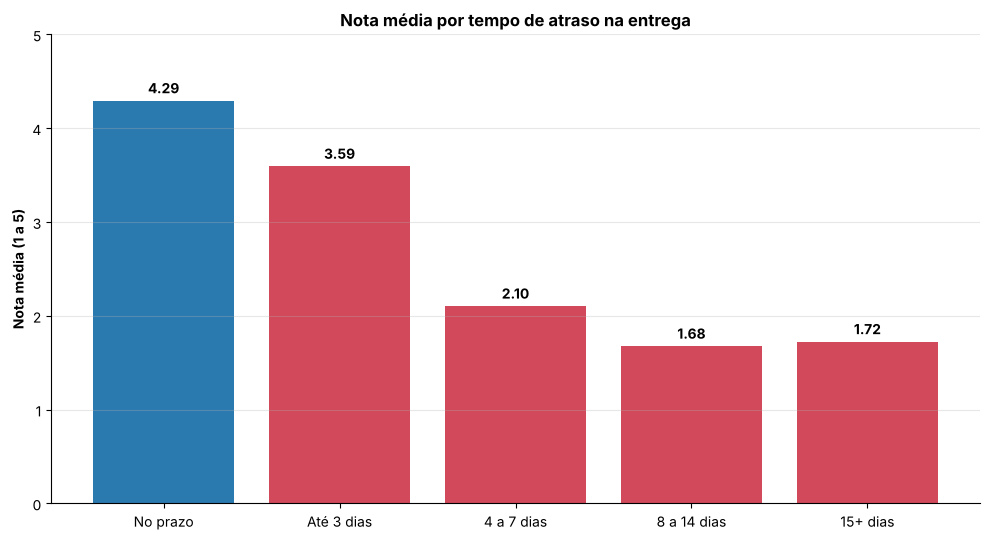

In [5]:
nota_no_prazo = resumo.loc["No prazo", "nota_media"]

rotulos = ["No prazo"] + list(nota_faixa.index.astype(str))
valores = [nota_no_prazo] + list(nota_faixa["nota_media"])
cores = ["#2a7ab0"] + ["#d1495b"] * len(nota_faixa)

fig, ax = plt.subplots(figsize=(10, 5.5))
barras = ax.bar(rotulos, valores, color=cores)
ax.bar_label(barras, fmt="%.2f", padding=3, fontweight="bold")

ax.set_title("Nota média por tempo de atraso na entrega", fontweight="bold")
ax.set_ylabel("Nota média (1 a 5)", fontweight="bold")
ax.set_ylim(0, 5)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(IMG / "nota_por_atraso.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Concentração geográfica

In [6]:
pedidos_clientes = pedidos.merge(clientes, on="customer_id")

clientes_estado = (
    pedidos_clientes.drop_duplicates("customer_unique_id")["customer_state"]
    .value_counts(normalize=True)
    .mul(100)
)

pagamentos_pedido = pagamentos.groupby("order_id", as_index=False)["payment_value"].sum()
fat_estado = (
    pagamentos_pedido.merge(pedidos_clientes[["order_id", "customer_state"]], on="order_id")
    .groupby("customer_state")["payment_value"].sum()
)
fat_estado = fat_estado / fat_estado.sum() * 100

geo = pd.DataFrame({"pct_clientes": clientes_estado, "pct_faturamento": fat_estado})
geo = geo.sort_values("pct_clientes", ascending=False)

print(f"SP + RJ + MG: {geo['pct_clientes'].head(3).sum():.1f}% dos clientes "
      f"e {geo['pct_faturamento'].head(3).sum():.1f}% do faturamento")
geo.head(5)

SP + RJ + MG: 66.5% dos clientes e 62.6% do faturamento


,pct_clientes,pct_faturamento
customer_state,,
SP,41.93,37.47
RJ,12.88,13.39
MG,11.71,11.70
RS,5.49,5.57
PR,5.08,5.07


In [7]:
atraso_estado = (
    entregues.merge(clientes, on="customer_id")
    .groupby("customer_state")
    .agg(pct_atraso=("atrasado", "mean"), pedidos=("order_id", "count"))
)
atraso_estado["pct_atraso"] *= 100

# Apenas estados com volume relevante (mais de 500 pedidos entregues)
atraso_estado.query("pedidos > 500").sort_values("pct_atraso", ascending=False).head(6)

,pct_atraso,pedidos
customer_state,,
MA,19.67,717
CE,15.32,1279
BA,14.04,3256
RJ,13.47,12353
PA,12.37,946
ES,12.23,1995


## 4. Categorias: volume × faturamento

In [8]:
cat = (
    itens.merge(produtos, on="product_id")
    .groupby("product_category_name")
    .agg(itens_vendidos=("order_item_id", "count"),
         faturamento=("price", "sum"),
         preco_medio=("price", "mean"))
)
cat["pct_faturamento"] = cat["faturamento"] / cat["faturamento"].sum() * 100

print("Top 5 por volume")
display(cat.sort_values("itens_vendidos", ascending=False).head(5))
print("Top 5 por faturamento")
display(cat.sort_values("faturamento", ascending=False).head(5))

Top 5 por volume


,itens_vendidos,faturamento,preco_medio,pct_faturamento
product_category_name,,,,
cama_mesa_banho,11115,"1,036,988.68",93.30,7.73
beleza_saude,9670,"1,258,681.34",130.16,9.38
esporte_lazer,8641,"988,048.97",114.34,7.37
moveis_decoracao,8334,"729,762.49",87.56,5.44
informatica_acessorios,7827,"911,954.32",116.51,6.80


Top 5 por faturamento


,itens_vendidos,faturamento,preco_medio,pct_faturamento
product_category_name,,,,
beleza_saude,9670,"1,258,681.34",130.16,9.38
relogios_presentes,5991,"1,205,005.68",201.14,8.98
cama_mesa_banho,11115,"1,036,988.68",93.30,7.73
esporte_lazer,8641,"988,048.97",114.34,7.37
informatica_acessorios,7827,"911,954.32",116.51,6.80


## 5. Parcelamento e valor da compra

In [9]:
faixas = pd.cut(
    pagamentos["payment_installments"],
    bins=[-1, 1, 5, 10, 100],
    labels=["1x", "2x a 5x", "6x a 10x", "Mais de 10x"],
)

parcelas = pagamentos.groupby(faixas, observed=True)["payment_value"].agg(
    valor_medio="mean", transacoes="count"
)
parcelas["pct_transacoes"] = parcelas["transacoes"] / parcelas["transacoes"].sum() * 100
parcelas

,valor_medio,transacoes,pct_transacoes
payment_installments,,,
1x,112.42,52548,50.58
2x a 5x,147.55,35211,33.89
6x a 10x,303.04,15786,15.20
Mais de 10x,358.34,341,0.33


## 6. Conclusões

- Pedidos atrasados têm nota média **~1,7 ponto menor** que os entregues no prazo, e a nota cai conforme o atraso aumenta.
- **SP, RJ e MG** concentram cerca de dois terços dos clientes; alguns estados do Nordeste e o RJ têm as maiores taxas de atraso.
- As categorias que mais vendem em volume não são as que mais faturam: `relogios_presentes` tem preço médio alto e fica em 2º lugar no faturamento.
- Compras parceladas em 6x ou mais têm valor médio bem acima das compras à vista.